In [1]:
import os
import sys
import pandas as pd
import yaml 
from matplotlib import pyplot as plt
from matplotlib import ticker as mticker
from matplotlib import colors as mcolors
from matplotlib import patches as mpatches
import statsmodels.api as sm
import numpy as np
from itertools import product
import subprocess

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 11
#plt.rcParams['text.usetex'] = True

from sklearn.decomposition import PCA

with open("../../config.yaml.local", "r") as f:
    LOCAL_CONFIG = yaml.safe_load(f)
with open("../../config.yaml", "r") as f:
    CONFIG = yaml.safe_load(f)
sys.path.append("../python")

import globals
import data_tools as dt
import writing_tools as wt
import utils
import emb

LOCAL_PATH = LOCAL_CONFIG["LOCAL_PATH"]
RAW_DATA_PATH = LOCAL_CONFIG["RAW_DATA_PATH"]
DATA_PATH = LOCAL_CONFIG["DATA_PATH"]
R_PATH = LOCAL_CONFIG["R_PATH"]

RUN_R_SCRIPTS = False
REPLACE_ANALYSIS_DATA = False

TITLE_PCA_K = 10
TEXT_PCA_K = 10
NUM_COMPONENTS_SHOW = 30


In [2]:
df = dt.get_post_quality_analysis_data()
df = df.loc[df['title'] != 'deleted by author'].reset_index(drop=True)


c:\Users\ekung\projects\sn-research\src\notebooks\../python\data_tools.py:89: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  return x.dt.to_period('W-SAT').dt.start_time
c:\Users\ekung\projects\sn-research\src\notebooks\../python\data_tools.py:89: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  return x.dt.to_period('W-SAT').dt.start_time


In [3]:
df_notext = df.loc[df['text'].str.len()==0].reset_index(drop=True)
df_notext["no_text"] = True
len(df_notext)

90117

In [4]:
df_text = df.loc[df['text'].str.len()>0].reset_index(drop=True)
df_text["no_text"] = False
len(df_text)

85740

In [5]:
# Dynamically process embeddings instead of loading from
# post_embeddings.pkl to save on memory

text_embeddings = []

for idx, row in df_text.iterrows():
    text_emb = np.array(emb.get_embedding_robust(row['text']))
    text_emb = text_emb / np.linalg.norm(text_emb)
    text_embeddings.append(text_emb)

text_embeddings = np.array(text_embeddings)    


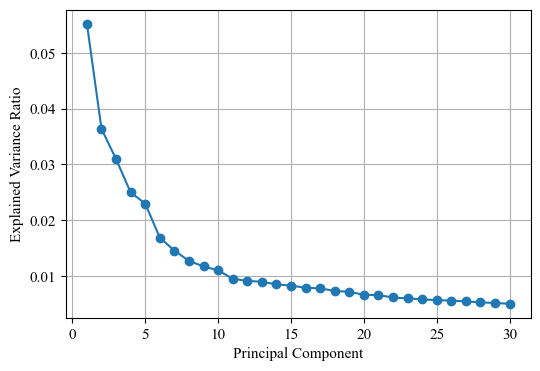

In [6]:
# scree plot for text embeddings

text_pca = PCA()
text_pca.fit(text_embeddings)
explained_variance = text_pca.explained_variance_ratio_[0:NUM_COMPONENTS_SHOW]
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o')
#plt.title('Text Embeddings: PCA Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.grid()
filename = os.path.join(LOCAL_PATH, 'results', 'fig_text_scree_plot.pdf')
plt.savefig(filename, bbox_inches='tight')
plt.show()

tex = r"""
\begin{figure}[H]
\caption{Scree Plot for Post Text Embeddings}
\label{fig_text_scree_plot}
\vspace{-0.6cm}
\begin{center}
\begin{adjustbox}{width=\textwidth}
\includegraphics{results/fig_text_scree_plot.pdf}
\end{adjustbox}
\end{center}
\footnotesize \textit{Note:} Shows the scree plot for post text embeddings, indicating the explained variance ratio for each principal component. 
The total explained variance at $K=10$ is \gn{TextPCAPctExplained}\%.
\end{figure}
"""
with open(os.path.join(LOCAL_PATH, "results", "fig_text_scree_plot.tex"), "w") as f:
    f.write(tex)




In [7]:
# How much does our choice of K explain?

TextPCAPctExplained = np.sum(text_pca.explained_variance_ratio_[0:TEXT_PCA_K])

RESULTS = {
    "TextPCAPctExplained": f"{TextPCAPctExplained*100:.1f}",
    "TextPCAK": f"{TEXT_PCA_K}",
    "NumPCAComponentsShow": f"{NUM_COMPONENTS_SHOW}",
    "PCAFirstExplain": f"{explained_variance[0]*100:.1f}",
    "PCASecondExplain": f"{explained_variance[1]*100:.1f}",
    "PCAThirdExplain": f"{explained_variance[2]*100:.1f}"
}

_ = wt.update_results(RESULTS)

RESULTS

{'TextPCAPctExplained': '23.7',
 'TextPCAK': '10',
 'NumPCAComponentsShow': '30',
 'PCAFirstExplain': '5.5',
 'PCASecondExplain': '3.6',
 'PCAThirdExplain': '3.1'}

In [8]:
# PCA for embeddings

text_pca = PCA(n_components=TEXT_PCA_K)
text_pca.fit(text_embeddings)
text_pca_embeddings = text_pca.transform(text_embeddings)
for k in range(TEXT_PCA_K):
    df_text[f'text_emb_{k}'] = text_pca_embeddings[:, k]
    df_notext[f'text_emb_{k}'] = 0.0


In [9]:
# Output data with reduced embeddings to file

out_df = pd.concat([df_text, df_notext], axis=0).reset_index(drop=True)

cols = ['itemId', 'no_text'] + [f'text_emb_{k}' for k in range(TEXT_PCA_K)]
out_df[cols].to_parquet(os.path.join(DATA_PATH, "post_embeddings_pca.parquet"), index=False)